In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
file_path = r"M:/accenture/ds-ml-training/ds-ai-assignments-maksym-bondar/weeks/week2/data/day.csv"
df = pd.read_csv(file_path)

In [25]:
df = df.copy()
df = df.drop(columns=["casual", "registered"]) # because cnt = casual + registered the target depends on them

XGBoost with 2 numeric features from dataset: 

temp - normalized temperature

windspeed - normalized wind speed

In [26]:
X = df[["temp", "windspeed"]].values   
y = df["cnt"].values                  

In [27]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=17
)

In [28]:
xgb_reg = XGBRegressor(
    random_state=17,
    n_estimators=100,     
    learning_rate=0.1,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0
)

xgb_reg.fit(X_train, y_train)
y_valid_pred = xgb_reg.predict(X_valid)

In [29]:
y_pred = xgb_reg.predict(X_train)

mape = mean_absolute_percentage_error(y_train, y_pred) * 100
print("MAPE:", mape)

MAPE: 26.248103380203247


RMSE (root mean squared error)

In [7]:
rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
rmse

np.float64(1562.5587988936609)

Let's make the model much richer with more features.

For example, 

Calendar / categorical-like:

season, yr, mnth, holiday, weekday, workingday, weathersit

Continuous:

temp, atemp, hum, windspeed

In [8]:
feature_cols = [
    "season", "yr", "mnth", "holiday", "weekday", "workingday",
    "weathersit", "temp", "atemp", "hum", "windspeed"
]

df_model = df[feature_cols + ["cnt"]].copy()

One-hot encode categorical features

In [9]:
cat_cols = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
num_cols = ["temp", "atemp", "hum", "windspeed"]

df_dummies = pd.get_dummies(df_model, columns=cat_cols, drop_first=False)

X_full = df_dummies.drop(columns=["cnt"]).values
y_full = df_dummies["cnt"].values

In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_full, y_full, test_size=0.3, random_state=17
)

In [11]:
xgb_reg_full = XGBRegressor(
    random_state=17,
    n_estimators=500,      
    learning_rate=0.05,   
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0
)

xgb_reg_full.fit(X_train, y_train)
y_valid_pred_full = xgb_reg_full.predict(X_valid)

rmse_full = np.sqrt(mean_squared_error(y_valid, y_valid_pred_full))
rmse_full

np.float64(664.5645660882019)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=17
)


In [34]:

xgb_final = XGBRegressor(
    random_state=17,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0
)

xgb_final.fit(X_train, y_train)

y_pred = xgb_final.predict(X_test)


In [35]:

mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print("MAPE:", mape)

MAPE: 15.437465906143188


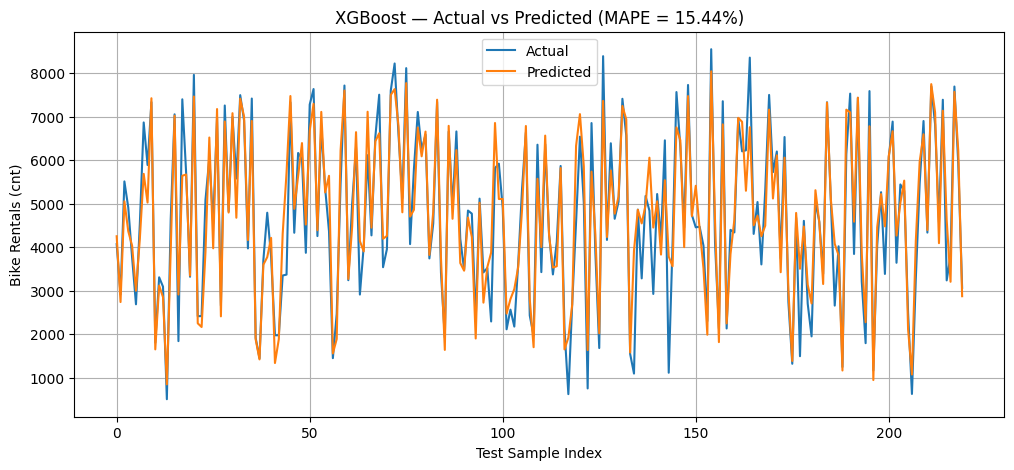

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title(f"XGBoost — Actual vs Predicted (MAPE = {mape:.2f}%)")
plt.xlabel("Test Sample Index")
plt.ylabel("Bike Rentals (cnt)")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
y_pred_valid = xgb_final.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
r2 = r2_score(y_valid, y_pred_valid)

rmse, r2

(np.float64(35.69545014610143), 0.9996615052223206)

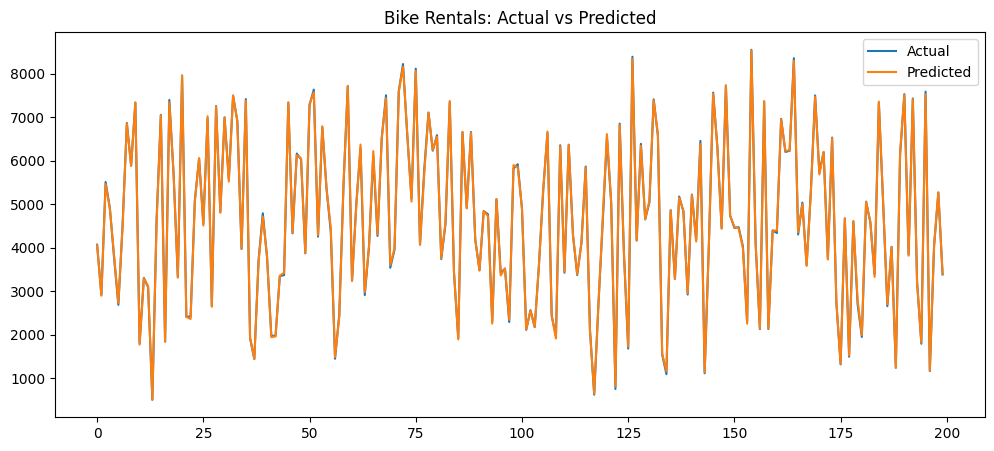

In [14]:
plt.figure(figsize=(12,5))
plt.plot(y_valid[:200], label="Actual")
plt.plot(y_pred_valid[:200], label="Predicted")
plt.legend()
plt.title("Bike Rentals: Actual vs Predicted")
plt.show()

In [15]:
importances = xgb_final.feature_importances_
feat_names = df_dummies.drop(columns=["cnt"]).columns

pd.DataFrame({"feature": feat_names, "importance": importances}) \
    .sort_values("importance", ascending=False)

,feature,importance
8,yr_0,0.250095
9,yr_1,0.226921
4,season_1,0.109745
35,weathersit_3,0.079285
7,season_4,0.064126
0,temp,0.041332
1,atemp,0.029555
33,weathersit_1,0.019472
34,weathersit_2,0.011912
22,holiday_0,0.011742
